## Imports and Functions

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


import os
from pathlib import Path
import numpy as np
from pynwb import read_nwb
from matplotlib import pyplot as plt

from CSE583_humanSayMonkeyDo.load_config import load_config, get_config_value, get_data_paths


def get_nwbs(primate='monkey', max_subjects=None):
    """Return absolute Path objects for all data directories.

    Args:
        primate (str): 'monkey' or 'human' to specify
        max_subjects (int, optional): Maximum number of subjects to return. Defaults to None.
    Returns:
        dict: Dictionary with keys 'monkey' and 'human' mapping to lists of Path objects.
    """
    assert primate in ['monkey', 'human'], "primate must be 'monkey' or 'human'"
    assert (max_subjects is None) or (isinstance(max_subjects, int) and max_subjects > 0), "max_subjects must be a positive integer or None"
    
    data_paths = get_data_paths()
    nwb = list(data_paths[primate].glob("**/*.nwb"))
    if max_subjects is not None:
        nwb = nwb[:max_subjects]
    return nwb

def get_pos_chunk(hdf_dataset, start_times, end_times):
    """Extract chunks of data from an HDF5 dataset based on start and end times.
    
    Args:
        hdf_dataset: HDF5 dataset object with time-indexed data.
        start_times (list): List of start times for each chunk.
        end_times (list): List of end times for each chunk.
    
    Returns:
        list: List of numpy arrays containing the extracted data chunks.
    """
    # Assertions
    assert hdf_dataset is not None, "hdf_dataset cannot be None"
    assert hasattr(hdf_dataset, 'timestamps'), "hdf_dataset must have a 'timestamps' attribute"
    assert hasattr(hdf_dataset, 'data'), "hdf_dataset must have a 'data' attribute"
    assert len(start_times) == len(end_times), "start_times and end_times must have the same length"
    
    # Convert to numpy arrays once
    start_times = np.asarray(start_times)
    end_times = np.asarray(end_times)
    
    # Sort by start times for efficient sequential access
    sort_idx = np.argsort(start_times)
    sorted_start_times = start_times[sort_idx]
    sorted_end_times = end_times[sort_idx]
    
    # Get timestamps once (avoid repeated attribute access)
    timestamps = hdf_dataset.timestamps[:]
    
    # Vectorized searchsorted for all start/end times at once
    start_indices = np.searchsorted(timestamps, sorted_start_times, side='left')
    end_indices = np.searchsorted(timestamps, sorted_end_times, side='right')
    
    # Extract chunks
    chunks = []
    for start_idx, end_idx in zip(start_indices, end_indices):
        if start_idx < end_idx:  # Only add non-empty chunks
            chunk = hdf_dataset.data[start_idx:end_idx, :]
            chunks.append(chunk)
        else:
            chunks.append(np.array([]))  # Empty chunk
    
    return chunks

def get_windowed_pos_chunk(hdf_dataset, center_times, window_size):
    """Extract windowed chunks of data from an HDF5 dataset based on center times and window size.

    Args:
        hdf_dataset: HDF5 dataset object with time-indexed data.
        center_times (list): List of center times for each chunk.
        window_size (list): Two floats specifying the window size before and after the center time.
    Returns:
        numpy.ndarray: Array containing the extracted data chunks.
    """
    assert len(window_size) == 2, "window_size must be a list of two floats"
    start_times = [ct - window_size[0] for ct in center_times]
    end_times = [ct + window_size[1] for ct in center_times]
    return get_pos_chunk(hdf_dataset, start_times, end_times)


def get_chunk_spikes(list_units_spkts, start_times, end_times, return_format='list'):
    """Extract spike times from a list of units based on start and end times.
    
    Args:
        list_units_spkts: List of spike times for each unit (each element is array-like).
        start_times (list): List of start times for each chunk.
        end_times (list): List of end times for each chunk.
        return_format (str): 'list', 'dict', or 'ragged' for output format.
    
    Returns:
        If return_format='list': List of shape [n_chunks][n_units] containing spike arrays
        If return_format='dict': Dict with keys 'spikes', 'counts', 'chunk_times'
        If return_format='ragged': Ragged array structure with metadata
    """
    # Convert to numpy arrays for faster operations
    start_times = np.asarray(start_times)
    end_times = np.asarray(end_times)
    n_chunks = len(start_times)
    n_units = len(list_units_spkts)
    
    # Pre-convert all units to numpy arrays once
    units_array = [np.asarray(unit) for unit in list_units_spkts]
    
    # Pre-allocate result structure
    chunked_list = [[None for _ in range(n_units)] for _ in range(n_chunks)]
    
    # Vectorized approach: use searchsorted for each unit
    for unit_idx, spikes in enumerate(units_array):
        if len(spikes) == 0:
            # Handle empty units
            for chunk_idx in range(n_chunks):
                chunked_list[chunk_idx][unit_idx] = np.array([])
            continue
            
        # Find indices for all chunks at once using searchsorted
        start_indices = np.searchsorted(spikes, start_times, side='left')
        end_indices = np.searchsorted(spikes, end_times, side='right')
        
        # Extract spikes for each chunk
        for chunk_idx in range(n_chunks):
            start_idx = start_indices[chunk_idx]
            end_idx = end_indices[chunk_idx]
            chunked_list[chunk_idx][unit_idx] = spikes[start_idx:end_idx]
    
    if return_format == 'dict':
        return {
            'spikes': chunked_list,
            'counts': [[len(chunked_list[c][u]) for u in range(n_units)] 
                       for c in range(n_chunks)],
            'chunk_times': list(zip(start_times, end_times)),
            'n_units': n_units,
            'n_chunks': n_chunks
        }
    elif return_format == 'ragged':
        # Return as structured array with metadata
        return {
            'data': chunked_list,
            'spike_counts': np.array([[len(chunked_list[c][u]) for u in range(n_units)] 
                                      for c in range(n_chunks)]),
            'start_times': start_times,
            'end_times': end_times
        }
    else:
        return chunked_list


def get_chunk_spikes_binned(list_units_spkts, start_times, end_times, bin_size=0.001):
    """Extract and bin spike times into fixed-size bins for array output.
    
    Args:
        list_units_spkts: List of spike times for each unit.
        start_times (list): List of start times for each chunk.
        end_times (list): List of end times for each chunk.
        bin_size (float): Size of time bins in seconds.
    
    Returns:
        numpy.ndarray: 3D array of shape [n_chunks, n_units, n_bins] with spike counts
        dict: Metadata including bin_edges, actual_times, etc.
    """
    start_times = np.asarray(start_times)
    end_times = np.asarray(end_times)
    n_chunks = len(start_times)
    n_units = len(list_units_spkts)
    
    # Calculate number of bins for each chunk
    chunk_durations = end_times - start_times
    n_bins_per_chunk = np.ceil(chunk_durations / bin_size).astype(int)
    max_bins = n_bins_per_chunk.max()
    
    # Pre-allocate 3D array
    binned_spikes = np.zeros((n_chunks, n_units, max_bins), dtype=np.int32)
    
    # Convert units to numpy arrays
    units_array = [np.asarray(unit) for unit in list_units_spkts]
    
    # Bin spikes for each chunk and unit
    for chunk_idx, (start, end, n_bins) in enumerate(zip(start_times, end_times, n_bins_per_chunk)):
        bin_edges = np.linspace(start, end, n_bins + 1)
        
        for unit_idx, spikes in enumerate(units_array):
            # Extract spikes in this chunk
            mask = (spikes >= start) & (spikes <= end)
            chunk_spikes = spikes[mask]
            
            if len(chunk_spikes) > 0:
                # Bin the spikes
                counts, _ = np.histogram(chunk_spikes, bins=bin_edges)
                binned_spikes[chunk_idx, unit_idx, :n_bins] = counts
    
    metadata = {
        'bin_size': bin_size,
        'n_bins_per_chunk': n_bins_per_chunk,
        'start_times': start_times,
        'end_times': end_times,
        'chunk_durations': chunk_durations
    }
    
    return binned_spikes, metadata

def get_chunk_spikes_binned_windowed(list_units_spkts, center_times, window_size, bin_size=0.001):
    start_times = [ct - window_size[0] for ct in center_times]
    end_times = [ct + window_size[1] for ct in center_times]
    return get_chunk_spikes_binned(list_units_spkts, start_times, end_times, bin_size=bin_size)


def get_chunk_spikes_aligned(list_units_spkts, start_times, end_times, max_duration=None):
    """Extract spikes and pad to create aligned 3D array.
    
    Args:
        list_units_spkts: List of spike times for each unit.
        start_times (list): List of start times for each chunk.
        end_times (list): List of end times for each chunk.
        max_duration (float): Maximum duration to consider. If None, uses longest chunk.
    
    Returns:
        numpy.ndarray: 3D array [n_chunks, n_units, max_spikes] with spike times (relative to chunk start)
        numpy.ndarray: 3D array [n_chunks, n_units, max_spikes] with valid spike mask
        dict: Metadata
    """
    start_times = np.asarray(start_times)
    end_times = np.asarray(end_times)
    n_chunks = len(start_times)
    n_units = len(list_units_spkts)
    
    units_array = [np.asarray(unit) for unit in list_units_spkts]
    
    # First pass: find maximum number of spikes in any chunk for any unit
    max_spikes = 0
    spike_lists = [[None for _ in range(n_units)] for _ in range(n_chunks)]
    
    for unit_idx, spikes in enumerate(units_array):
        start_indices = np.searchsorted(spikes, start_times, side='left')
        end_indices = np.searchsorted(spikes, end_times, side='right')
        
        for chunk_idx in range(n_chunks):
            chunk_spikes = spikes[start_indices[chunk_idx]:end_indices[chunk_idx]]
            # Convert to relative times
            relative_spikes = chunk_spikes - start_times[chunk_idx]
            spike_lists[chunk_idx][unit_idx] = relative_spikes
            max_spikes = max(max_spikes, len(relative_spikes))
    
    # Second pass: create padded arrays
    spike_array = np.full((n_chunks, n_units, max_spikes), np.nan, dtype=np.float32)
    valid_mask = np.zeros((n_chunks, n_units, max_spikes), dtype=bool)
    
    for chunk_idx in range(n_chunks):
        for unit_idx in range(n_units):
            spikes = spike_lists[chunk_idx][unit_idx]
            n_spikes = len(spikes)
            if n_spikes > 0:
                spike_array[chunk_idx, unit_idx, :n_spikes] = spikes
                valid_mask[chunk_idx, unit_idx, :n_spikes] = True
    
    metadata = {
        'max_spikes': max_spikes,
        'start_times': start_times,
        'end_times': end_times,
        'spike_counts': valid_mask.sum(axis=2)  # [n_chunks, n_units]
    }
    
    return spike_array, valid_mask, metadata


def plot_firing_rate_heatmap(firing_rates_2d, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None):
    """Plot firing rate heatmap for a 2D matrix.
    
    Args:
        firing_rates_2d: 2D array [n_units, n_timepoints] - spike counts or firing rates
        time_axis: Array of time values for x-axis. If None, uses indices.
        bin_size: Time bin size in seconds. If provided, converts counts to rates (Hz)
        figsize: Figure size tuple
        cmap: Colormap name ('viridis', 'hot', 'plasma', etc.)
        vmin, vmax: Color scale limits (None = auto)
        title: Plot title (None = default title)
    
    Returns:
        fig, ax: Figure and axis objects
    """
    # Convert to numpy array if needed
    firing_rates_2d = np.asarray(firing_rates_2d)
    n_units, n_timepoints = firing_rates_2d.shape
    
    # Convert spike counts to firing rates if bin_size provided
    if bin_size is not None:
        data_to_plot = firing_rates_2d / bin_size
        rate_label = 'Firing Rate (Hz)'
    else:
        data_to_plot = firing_rates_2d
        rate_label = 'Spike Count'
    
    # Create time axis if not provided
    if time_axis is None:
        time_axis = np.arange(n_timepoints)
        xlabel = 'Time Bin'
    else:
        time_axis = np.asarray(time_axis)
        xlabel = 'Time (s)'
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    im = ax.imshow(data_to_plot, 
                   aspect='auto',
                   cmap=cmap,
                   interpolation='nearest',
                   extent=[time_axis[0], time_axis[-1], n_units, 0],
                   vmin=vmin, vmax=vmax)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label=rate_label)
    
    # Labels and title
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Unit Number', fontsize=12)
    
    if title is None:
        title = 'Neural Population Firing Rate'
    ax.set_title(title, fontsize=14)
    
    plt.tight_layout()
    return fig, ax


def get_movement_onset_times(velocity_dataset, go_cue_times, threshold=5.0, 
                             window=[-0.1, 1.0]):
    """Find movement onset times when velocity exceeds threshold after go cues.
    
    Args:
        velocity_dataset: HDF5 dataset with velocity data and timestamps
        go_cue_times (array): Times of go cues
        threshold (float): Velocity magnitude threshold for movement onset
        window (list): Time window [start, end] relative to go cue (seconds)
    
    Returns:
        movement_onset_times (array): Timestamps of movement onsets
        movement_onset_indices (array): Indices into velocity_dataset where movement starts
    """
    # Get velocity chunks around go cues
    cursor_moving = get_windowed_pos_chunk(velocity_dataset, go_cue_times, window)
    
    # Find first index exceeding threshold for each trial
    first_idx = []
    for chunk in cursor_moving:
        magnitudes = np.linalg.norm(chunk, axis=1)
        idx = np.argmax(magnitudes > threshold)
        
        # Verify threshold was actually exceeded
        if magnitudes[idx] > threshold:
            first_idx.append(idx)
        else:
            first_idx.append(np.nan)  # No movement detected
    
    first_idx = np.array(first_idx)
    
    # Convert to absolute timestamps
    timestamps = velocity_dataset.timestamps[:]
    start_indices = np.searchsorted(timestamps, go_cue_times, side='left')
    
    # Calculate window start offset in indices
    window_start_offset = int(window[0] / np.median(np.diff(timestamps)))
    
    # Adjust for window offset
    movement_onset_indices = start_indices + window_start_offset + first_idx
    
    # Get actual timestamps (handle NaN cases)
    movement_onset_times = np.full(len(movement_onset_indices), np.nan)
    valid_mask = ~np.isnan(first_idx)
    movement_onset_times[valid_mask] = timestamps[movement_onset_indices[valid_mask].astype(int)]
    
    return movement_onset_times, movement_onset_indices


def train_lda_classifier(data_matrices, labels):
    """Train LDA classifier on matrix data.
    
    Args:
        data_matrices: List or array of shape [n_trials, n_features_1, n_features_2]
                      e.g., [n_trials, 18, 21]
        labels: Array of shape [n_trials] with values 0 or 1
    
    Returns:
        lda: Trained LDA classifier
        results: Dict with performance metrics
    """
    # Flatten each matrix into a vector
    # Shape: [n_trials, 18*21] = [n_trials, 378]
    X = np.array([matrix.flatten() for matrix in data_matrices])
    y = np.array(labels)
    
    print(f"Data shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Class distribution: 0={np.sum(y==0)}, 1={np.sum(y==1)}")
    
    # Split into train and test sets (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Train LDA classifier
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = lda.predict(X_train)
    y_test_pred = lda.predict(X_test)
    
    # Get prediction probabilities
    y_train_proba = lda.predict_proba(X_train)
    y_test_proba = lda.predict_proba(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Cross-validation score (5-fold)
    cv_scores = cross_val_score(lda, X, y, cv=5)
    
    results = {
        'lda': lda,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_train_proba': y_train_proba,
        'y_test_proba': y_test_proba,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    # Print results
    print("\n=== LDA Classification Results ===")
    print(f"Training Accuracy: {train_accuracy:.3f}")
    print(f"Test Accuracy: {test_accuracy:.3f}")
    print(f"Cross-validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(f"\nCV Scores: {cv_scores}")
    
    # Confusion matrix
    print("\n=== Test Set Confusion Matrix ===")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    
    # Classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_test_pred, target_names=['Class 0', 'Class 1']))
    
    return lda, results


def plot_lda_results(results):
    """Visualize LDA classification results."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Confusion Matrix
    ax = axes[0, 0]
    cm = confusion_matrix(results['y_test'], results['y_test_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(f'Confusion Matrix\nTest Accuracy: {results["test_accuracy"]:.3f}')
    
    # 2. Prediction Probabilities
    ax = axes[0, 1]
    for class_label in [0, 1]:
        mask = results['y_test'] == class_label
        proba = results['y_test_proba'][mask, 1]  # Probability of class 1
        ax.hist(proba, bins=20, alpha=0.6, label=f'True Class {class_label}')
    ax.set_xlabel('Predicted Probability (Class 1)')
    ax.set_ylabel('Count')
    ax.set_title('Prediction Probability Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. LDA Projection (1D)
    ax = axes[1, 0]
    lda = results['lda']
    X_test_lda = lda.transform(results['X_test'])
    
    for class_label in [0, 1]:
        mask = results['y_test'] == class_label
        ax.hist(X_test_lda[mask, 0], bins=20, alpha=0.6, label=f'Class {class_label}')
    ax.set_xlabel('LDA Component')
    ax.set_ylabel('Count')
    ax.set_title('LDA Projection')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Cross-validation scores
    ax = axes[1, 1]
    cv_scores = results['cv_scores']
    ax.bar(range(len(cv_scores)), cv_scores, color='skyblue', edgecolor='black')
    ax.axhline(y=cv_scores.mean(), color='r', linestyle='--', 
               label=f'Mean: {cv_scores.mean():.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Accuracy')
    ax.set_title('Cross-Validation Scores')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Using Data

In [18]:

#Get paths to monkey NWB files
monkey_paths = get_nwbs('monkey', 2)
#Load first NWB file
nwbfile = read_nwb(monkey_paths[0])
#Visualize entries
nwbfile


Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(100516, 2)"


Index(['start_time', 'stop_time', 'target_on_time', 'go_cue_time', 'target_id',
       'target_corners', 'target_dir', 'result'],
      dtype='object')


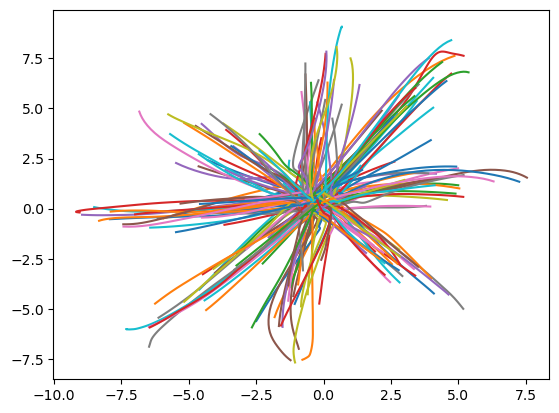

In [19]:
print(nwbfile.trials[:].keys())
# Lets view the data stored in the NWB file
cursor_pos = nwbfile.processing['behavior'].data_interfaces['Position'].spatial_series['cursor_pos']
go_cue_times = nwbfile.trials['go_cue_time'].data[:]
go_cue_times = go_cue_times[~np.isnan(go_cue_times)]  # Remove NaN values if any
window = [0.2, 0.5]  # 200 ms before to 500 ms after go cue

cursor_pos_chunks = get_windowed_pos_chunk(cursor_pos, go_cue_times, window)

for i, chunk in enumerate(cursor_pos_chunks):
    plt.plot(chunk[:,0],chunk[:,1])

In [20]:
list_units_spkts = nwbfile.units[:]['spike_times']

(220, 18, 71)
(18, 71)


(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Neural Population Firing Rate'}, xlabel='Time Bin', ylabel='Unit Number'>)

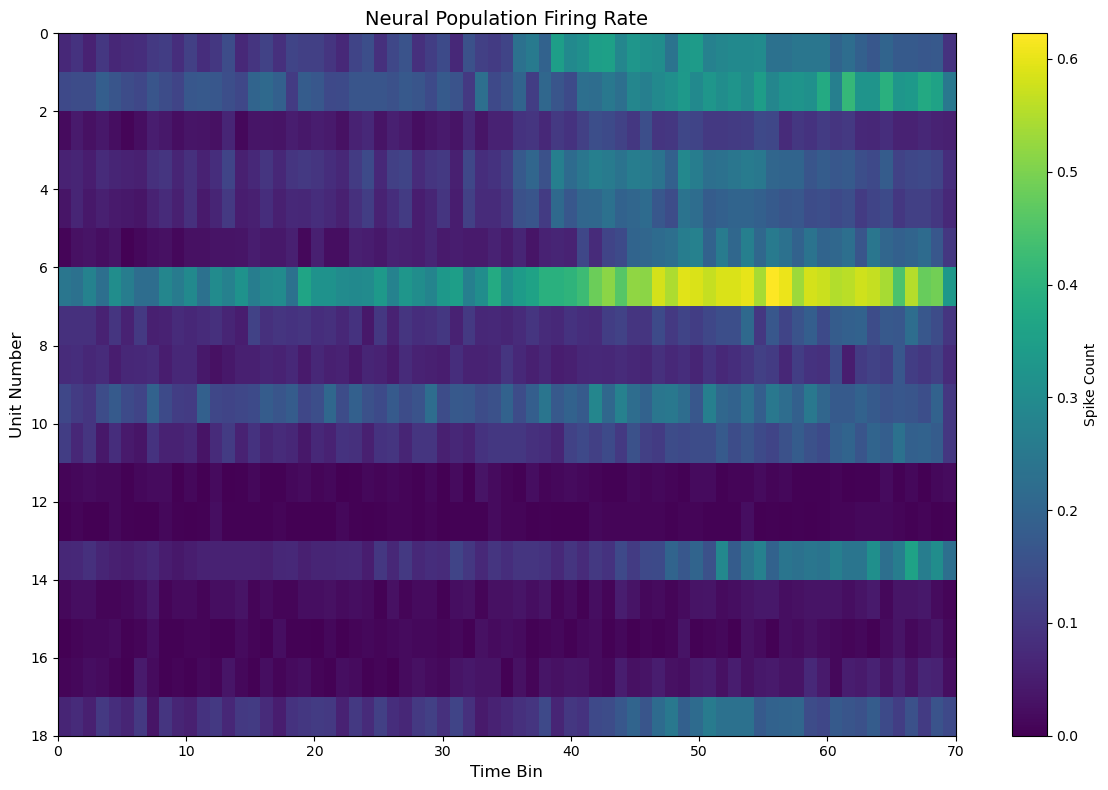

In [21]:
spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, go_cue_times, window, bin_size=0.01)
print(spike_data[0].shape)
avg_spike_rates = np.mean(spike_data[0],axis=0)
print(avg_spike_rates.shape)


plot_firing_rate_heatmap(avg_spike_rates, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None)


## Movement Detection

In [22]:

cursor_vel = nwbfile.processing['behavior'].data_interfaces['Velocity'].time_series['cursor_vel']

# Usage
movement_times, movement_indices = get_movement_onset_times(
    cursor_vel, 
    go_cue_times, 
    threshold=5.0,
    window=[-0.1, 1.0]
)

# Filter out trials with no movement detected
valid_trials = ~np.isnan(movement_times)
print(f"Movement detected in {valid_trials.sum()}/{len(go_cue_times)} trials")
print(f"First movement onset at: {movement_times[valid_trials][0]:.3f} seconds")



Movement detected in 220/220 trials
First movement onset at: 5.930 seconds


In [23]:
window = [0.0, 0.2]
movement_spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, movement_times[valid_trials], window, bin_size=0.01)



window = [0.2, 0.0]
stationary_spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, go_cue_times[valid_trials], window, bin_size=0.01)

data = movement_spike_data[0]
move_category = np.ones(movement_spike_data[0].shape[0], dtype=int)  # All ones for movement


data = np.concatenate([data, stationary_spike_data[0]], axis=0)
move_category = np.concatenate([move_category,
                           np.zeros(stationary_spike_data[0].shape[0], dtype=int)])  # All zeros for stationary


print(move_category.shape)
print(data.shape)



(440,)
(440, 18, 21)


Data shape: (440, 378)
Labels shape: (440,)
Class distribution: 0=220, 1=220

=== LDA Classification Results ===
Training Accuracy: 1.000
Test Accuracy: 0.591
Cross-validation Accuracy: 0.595 (+/- 0.076)

CV Scores: [0.47727273 0.56818182 0.57954545 0.69318182 0.65909091]

=== Test Set Confusion Matrix ===
[[29 15]
 [21 23]]

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.58      0.66      0.62        44
     Class 1       0.61      0.52      0.56        44

    accuracy                           0.59        88
   macro avg       0.59      0.59      0.59        88
weighted avg       0.59      0.59      0.59        88



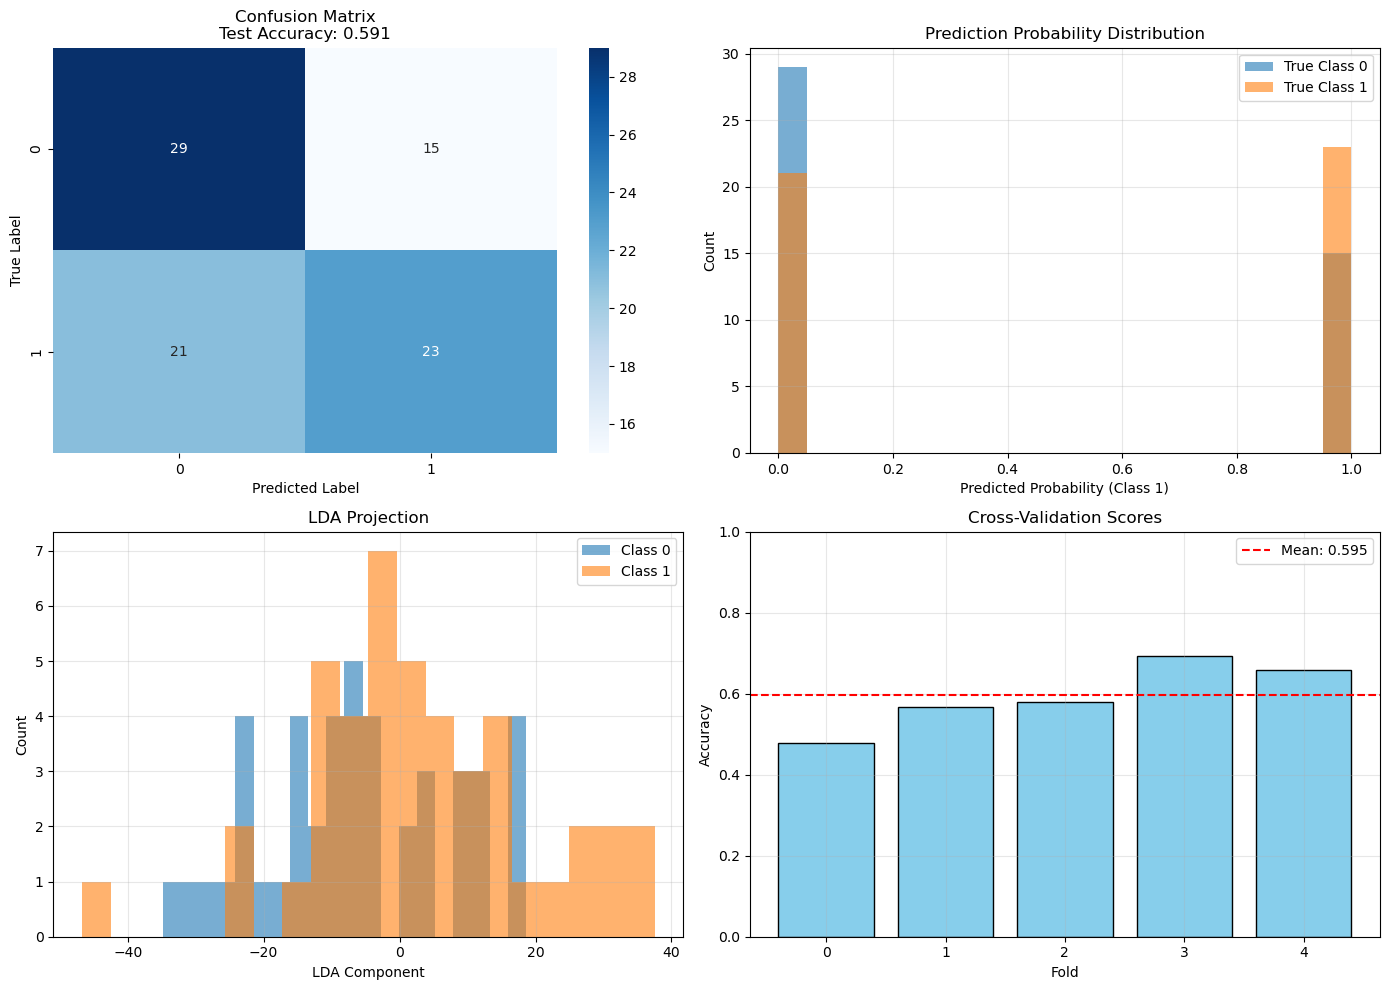

In [27]:



# Assuming you have:
# moving_spike_data: list of [18, 21] matrices for moving trials
# stationary_spike_data: list of [18, 21] matrices for stationary trials

# Combine data and create labels
#data_matrices = moving_spike_data + stationary_spike_data
#labels = np.concatenate([
#    np.ones(len(moving_spike_data), dtype=int),   # 1 for moving
#    np.zeros(len(stationary_spike_data), dtype=int)  # 0 for stationary
#])

# Train classifier
lda, results = train_lda_classifier(data, move_category)

# Visualize
plot_lda_results(results)